# XAI Limitations: Explanation Instability

**Chapter 12, Section 12.5**: Model Explainability with SHAP

## Purpose
This notebook demonstrates critical limitations of model explanations
that practitioners must understand before relying on SHAP for
downstream decisions (feature pruning, risk allocation, reporting).

## Learning Objectives
- Identify explanation instability: similar predictions with different SHAP profiles
- Demonstrate the Rashomon effect across model families (GBM vs Random Forest)
- Understand when SHAP attributions reflect model-specific fitting, not data truth

## Cross-References
- **Section 12.5**: Rashomon effect, explanation multiplicity
- **Related**: `08_shap_analysis` (SHAP fundamentals), `11_conformal_gbm` (UQ)

## 1. Setup

In [1]:
"""XAI Limitations — demonstrate explanation instability across seeds and model families."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from ml4t.diagnostic.metrics import cross_sectional_ic_series

warnings.filterwarnings("ignore")

import lightgbm as lgb
import shap
from sklearn.ensemble import RandomForestRegressor

from utils.modeling import load_modeling_dataset
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
MAX_SYMBOLS = 0
SEED = 42

In [3]:
set_global_seeds(SEED)

## 2. Load Data

In [4]:
mds = load_modeling_dataset("etfs", "fwd_ret_21d")
df = mds.dataset.to_pandas()
date_col = mds.date_col
FEATURE_COLS = mds.feature_names

# Use first walk-forward fold
split = mds.splits[0]
train_mask = (df[date_col] >= split["train_start"]) & (df[date_col] <= split["train_end"])
test_mask = (df[date_col] >= split["val_start"]) & (df[date_col] <= split["val_end"])

X_train = df.loc[train_mask, FEATURE_COLS].values
y_train = df.loc[train_mask, mds.label_col].values
X_test = df.loc[test_mask, FEATURE_COLS].values
y_test = df.loc[test_mask, mds.label_col].values

# Drop NaN labels
train_valid = np.isfinite(y_train)
test_valid = np.isfinite(y_test)
X_train, y_train = X_train[train_valid], y_train[train_valid]
X_test, y_test = X_test[test_valid], y_test[test_valid]

# Test dates and symbols for cross-sectional IC
test_entity_col = mds.entity_cols[0]
dates_test = df.loc[test_mask, date_col].values[test_valid]
symbols_test = df.loc[test_mask, test_entity_col].values[test_valid]


def cross_sectional_ic_mean(y_true, y_pred, dates, symbols):
    pred_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
    )
    ic_clean = ic_per_date.drop_nulls("ic")
    return float(ic_clean["ic"].mean()) if ic_clean.height else float("nan")


print(f"ETFs: {len(X_train):,} train / {len(X_test):,} test ({len(FEATURE_COLS)} features)")

ETFs: 227,101 train / 24,190 test (71 features)


## 3. Demonstration 1: Similar Predictions, Different Explanations

Two samples with nearly identical predictions can have entirely
different SHAP profiles — the model arrived at the same answer
through different reasoning paths.

In [5]:
model = lgb.LGBMRegressor(n_estimators=100, max_depth=4, random_state=SEED, verbose=-1)
model.fit(X_train, y_train)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
predictions = model.predict(X_test)

In [6]:
# Find pairs with similar predictions but different SHAP
n_samples = min(500, len(predictions))
prediction_diffs = np.abs(predictions[:n_samples, None] - predictions[None, :n_samples])
shap_diffs = np.sqrt(
    ((shap_values[:n_samples, None, :] - shap_values[None, :n_samples, :]) ** 2).sum(axis=2)
)

# Use generous thresholds: prediction diff in bottom 25%, SHAP diff in top 75%
pred_threshold = np.percentile(prediction_diffs[prediction_diffs > 0], 25)
shap_threshold = np.percentile(shap_diffs[shap_diffs > 0], 75)

mask = (prediction_diffs < pred_threshold) & (shap_diffs > shap_threshold) & (prediction_diffs > 0)
pairs = np.argwhere(mask)

In [7]:
print(f"Searched {n_samples} samples: {len(pairs)} instability pairs found")
print(f"  Prediction threshold: {pred_threshold:.6f}")
print(f"  SHAP distance threshold: {shap_threshold:.4f}")

if len(pairs) > 0:
    i, j = pairs[0]
    instability_df = pl.DataFrame(
        {
            "feature": FEATURE_COLS,
            f"SHAP (sample {i})": shap_values[i].round(4),
            f"SHAP (sample {j})": shap_values[j].round(4),
            "abs_diff": np.abs(shap_values[i] - shap_values[j]).round(4),
        }
    ).sort("abs_diff", descending=True)

    print(f"\nExample: samples {i} and {j}")
    print(f"  Prediction diff: {abs(predictions[i] - predictions[j]):.6f}")
    print(f"  SHAP Euclidean distance: {shap_diffs[i, j]:.4f}")
else:
    instability_df = pl.DataFrame(
        schema={
            "feature": str,
            "SHAP (sample a)": float,
            "SHAP (sample b)": float,
            "abs_diff": float,
        }
    )
    print("\nNo pairs met both thresholds — predictions and SHAP are tightly coupled")
    print("in this dataset. This is informative: it means the model's explanation")
    print("space is relatively stable for the ETF feature set.")
instability_df.head(10)

Searched 500 samples: 1288 instability pairs found
  Prediction threshold: 0.012519
  SHAP distance threshold: 0.0329

Example: samples 19 and 85
  Prediction diff: 0.011860
  SHAP Euclidean distance: 0.0347


feature,SHAP (sample 19),SHAP (sample 85),abs_diff
str,f64,f64,f64
"""yield_curve_slope""",-0.0116,-0.0318,0.0202
"""corr_spy_tlt_63d""",0.0095,-0.0072,0.0167
"""vol_ratio_short""",0.0011,0.0173,0.0162
"""macd_line""",-0.0061,0.0037,0.0099
"""mom_accel_medium""",-0.0,-0.0072,0.0072
"""yield_curve_zscore""",-0.0028,-0.0093,0.0065
"""skip_recent_6_1""",0.0002,-0.0043,0.0046
"""vol_63d_rank""",-0.0021,0.0022,0.0042
"""sharpe_42d""",-0.0024,0.0001,0.0025


**Interpretation**: SHAP explanations are not unique — the same prediction
can be reached through different feature contribution paths. When instability
pairs are found, the top-three SHAP contributors can differ completely even
when predictions agree to within fractions of a percent. For production
deployment, report confidence intervals on feature importance rather than
point estimates.

## 4. Demonstration 2: Rashomon Effect Across Model Families

Models with similar predictive performance can attribute predictions
to different features. We compare three LightGBM seeds plus a
Random Forest to demonstrate cross-architecture disagreement.

In [8]:
# Enable stochastic training (subsample < 1) so different seeds produce
# different models — without this, LightGBM is fully deterministic.
_lgb_kw = dict(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    verbose=-1,
)
model_configs = [
    ("LightGBM (seed=42)", lgb.LGBMRegressor(**_lgb_kw, random_state=42)),
    ("LightGBM (seed=123)", lgb.LGBMRegressor(**_lgb_kw, random_state=123)),
    ("LightGBM (seed=456)", lgb.LGBMRegressor(**_lgb_kw, random_state=456)),
    (
        "RandomForest",
        RandomForestRegressor(n_estimators=200, max_depth=6, random_state=SEED, n_jobs=-1),
    ),
]

In [9]:
model_results = []
importance_arrays = []

for name, m in model_configs:
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    ic = cross_sectional_ic_mean(y_test, pred, dates_test, symbols_test)

    exp = shap.TreeExplainer(m)
    sv = exp.shap_values(X_test)
    mean_abs = np.abs(sv).mean(axis=0)

    model_results.append({"model": name, "ic": round(ic, 4)})
    importance_arrays.append(mean_abs)

In [10]:
rashomon_df = pl.DataFrame(model_results)
rashomon_df

model,ic
str,f64
"""LightGBM (seed=42)""",-0.0374
"""LightGBM (seed=123)""",-0.0331
"""LightGBM (seed=456)""",-0.019
"""RandomForest""",0.0023


Across the four configurations the validation IC ranges from −0.037
(LightGBM seed 42) through −0.033 and −0.019 (seeds 123 and 456) up to
+0.002 (Random Forest). The three LightGBM seeds span a range (≈0.018)
on the same order as the gap from the nearest LightGBM seed to the
Random Forest (≈0.021) — stochastic training alone produces meaningful IC
variation, comparable to changing model family. The Rashomon point holds in
either direction: similar predictive performance, different feature
attributions.

In [11]:
# Show top-5 features per model
for i, (name, _) in enumerate(model_configs):
    order = np.argsort(importance_arrays[i])[::-1][:5]
    top5 = [(FEATURE_COLS[idx], round(importance_arrays[i][idx], 4)) for idx in order]
    print(f"{name}: {', '.join(f'{f} ({v})' for f, v in top5)}")

LightGBM (seed=42): yield_curve_slope (0.0145), corr_spy_tlt_63d (0.0087), yield_curve_zscore (0.0031), mom_accel_medium (0.0026), vol_ratio_medium (0.0024)
LightGBM (seed=123): yield_curve_slope (0.0152), corr_spy_tlt_63d (0.0094), yield_curve_zscore (0.0038), macd_line (0.0028), skip_recent_6_1 (0.0027)
LightGBM (seed=456): yield_curve_slope (0.0192), corr_spy_tlt_63d (0.0105), yield_curve_zscore (0.0052), dist_52w_low (0.003), mom_accel_medium (0.0025)
RandomForest: yield_curve_slope (0.0114), corr_spy_tlt_63d (0.0101), ret_126d (0.0034), skip_recent_6_1 (0.0022), yield_curve_zscore (0.002)


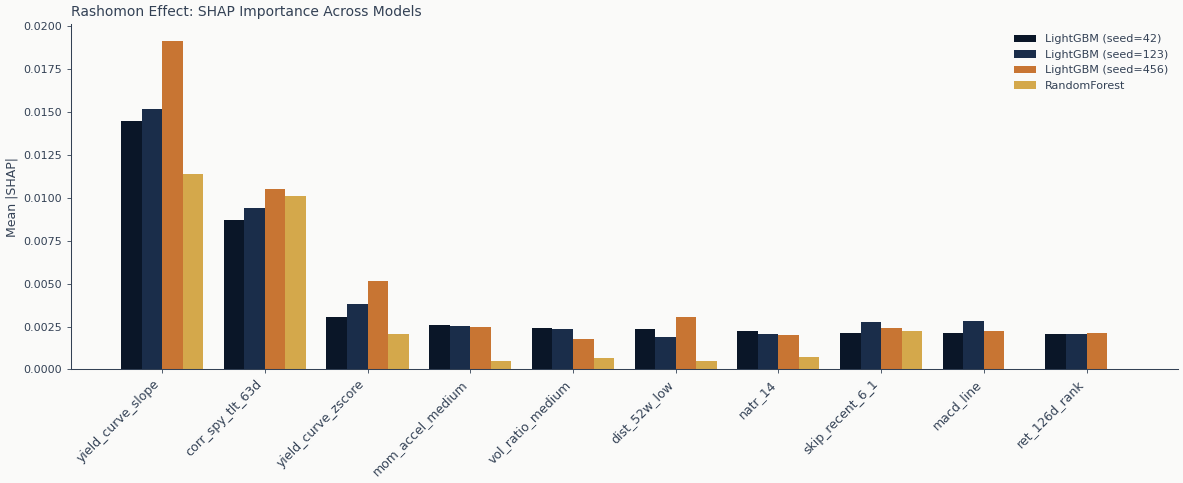

In [12]:
# Grouped bar chart comparing SHAP importance profiles
fig, ax = plt.subplots(figsize=(12, 5))
n_feat = min(10, len(FEATURE_COLS))
top_feats_idx = np.argsort(importance_arrays[0])[::-1][:n_feat]
feat_names = [FEATURE_COLS[idx] for idx in top_feats_idx]

x = np.arange(n_feat)
width = 0.2
colors = [COLORS["blue"], COLORS["slate"], COLORS["copper"], COLORS["amber"]]

for i, (name, _) in enumerate(model_configs):
    vals = [importance_arrays[i][idx] for idx in top_feats_idx]
    ax.bar(x + i * width, vals, width, label=name, color=colors[i])

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(feat_names, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Mean |SHAP|")
ax.set_title("Rashomon Effect: SHAP Importance Across Models")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation**: Features that rank highly across all four models
(both GBM and Random Forest) are more likely to reflect genuine data
structure. Features that only one family highlights may reflect
architecture-specific fitting patterns. When SHAP attributions
drive downstream decisions, validate across model specifications.

## 5. Stakeholder Guidance

| Audience | Recommended Explanation | Key Caveat |
|----------|------------------------|------------|
| Risk Manager | SHAP summary plot | Correlation $\neq$ causation |
| Trader | Feature importance rank | May vary with retraining |
| Regulator | Model documentation | Include confidence intervals |
| Quant Researcher | Full SHAP + interactions | Check stability across seeds |

## 6. Key Takeaways

1. **Explanation instability**: Samples with similar predictions can have
   different top SHAP contributors — the same output is reachable through
   different feature-contribution paths.

2. **Rashomon effect**: Models with different architectures or random seeds
   attribute predictions to different features — SHAP explanations reflect
   model-specific fitting patterns, not ground truth about the data.

3. **Best practices**: Report confidence intervals on feature importance,
   check stability across random seeds and model architectures, and never
   claim SHAP proves causation.

**Next**: See `08_shap_analysis` for SHAP fundamentals and drift detection,
or Section 12.5 in the chapter text for the theoretical framework.